# Cell 1 — Load data

In [0]:

import pandas as pd
import numpy as np

# Load scored output
scored = pd.read_parquet("/Volumes/workspace/default/retail_data/customer_segments_scored.parquet")
features = pd.read_parquet("/Volumes/workspace/default/retail_data/customer_features_engineered.parquet")

# Merge
df = features.merge(scored, on="Customer ID")

print("Shape:", df.shape)
print("\nSegment distribution:")
print(df["predicted_segment"].value_counts())
print(f"\n% distribution:")
print(df["predicted_segment"].value_counts(normalize=True).round(3) * 100)

Shape: (5878, 17)

Segment distribution:
predicted_segment
Potential    1684
Champions    1681
Loyal        1422
At Risk      1091
Name: count, dtype: int64

% distribution:
predicted_segment
Potential    28.6
Champions    28.6
Loyal        24.2
At Risk      18.6
Name: proportion, dtype: float64


# Cell 2 - Feature Distribution Monitoring


=== FEATURE STATS PER SEGMENT ===
                   total_spent  recency_days  num_invoices  avg_basket_value  purchase_frequency  num_unique_products
predicted_segment                                                                                                    
At Risk                 227.75        496.81          1.18            200.36                0.86                18.13
Champions              8192.12         38.62         15.52            457.25                0.03               178.41
Loyal                  1884.09        123.10          4.42            485.29                0.06                72.88
Potential               620.45        236.76          1.96            371.30                0.49                34.80


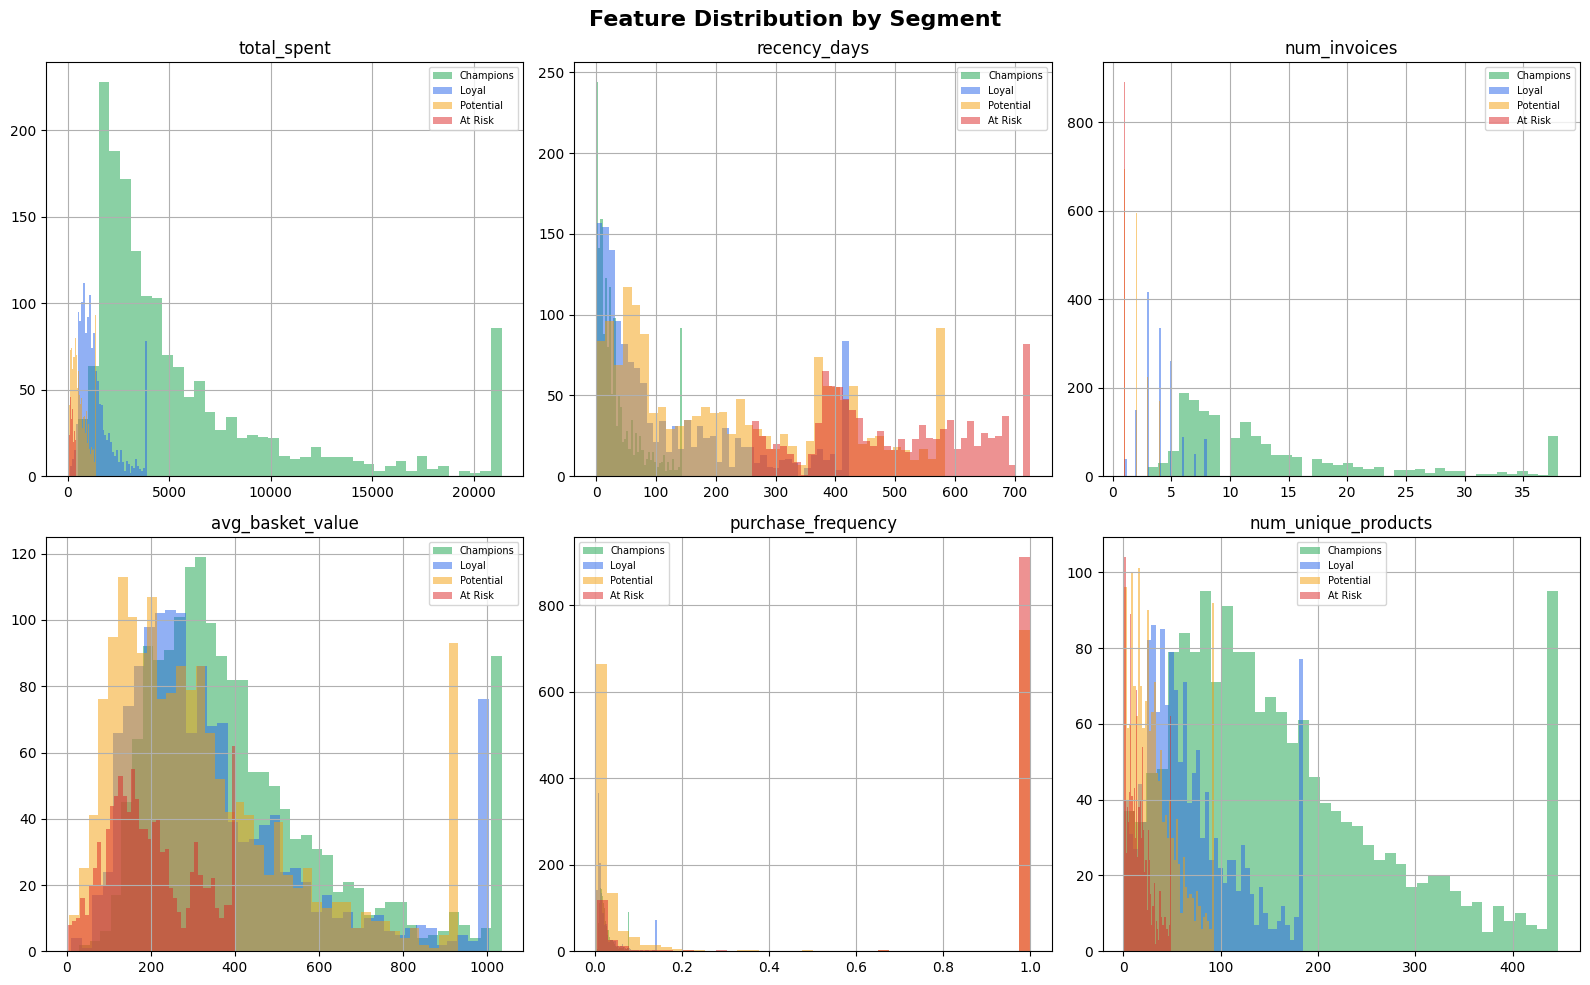


=== MISSING VALUES ===
total_spent            0
recency_days           0
num_invoices           0
avg_basket_value       0
purchase_frequency     0
num_unique_products    0
dtype: int64

=== OUTLIER CHECK (>3 std) ===
total_spent                   : 36 outliers (0.6%)
recency_days                  : 0 outliers (0.0%)
num_invoices                  : 62 outliers (1.1%)
avg_basket_value              : 20 outliers (0.3%)
purchase_frequency            : 70 outliers (1.2%)
num_unique_products           : 99 outliers (1.7%)


In [0]:
import matplotlib.pyplot as plt

monitor_features = [
    "total_spent", "recency_days", "num_invoices",
    "avg_basket_value", "purchase_frequency", "num_unique_products"
]

# Stats per segment
print("=== FEATURE STATS PER SEGMENT ===")
print(df.groupby("predicted_segment")[monitor_features].mean().round(2).to_string())

# Plot distribution per segment
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Feature Distribution by Segment", fontsize=16, fontweight="bold")

colors = {"Champions": "#16a34a", "Loyal": "#2563eb", "Potential": "#f59e0b", "At Risk": "#dc2626"}

for ax, feat in zip(axes.flatten(), monitor_features):
    for segment, color in colors.items():
        subset = df[df["predicted_segment"] == segment][feat]
        subset.clip(upper=subset.quantile(0.95)).hist(
            bins=40, ax=ax, alpha=0.5, label=segment, color=color
        )
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("monitoring_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Missing check
print("\n=== MISSING VALUES ===")
print(df[monitor_features].isnull().sum())

# Outlier check
print("\n=== OUTLIER CHECK (>3 std) ===")
for feat in monitor_features:
    mean, std = df[feat].mean(), df[feat].std()
    outliers = ((df[feat] - mean).abs() > 3 * std).sum()
    print(f"{feat:30s}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")

## Monitoring Report

### Segment Feature Profile:
| Segment | total_spent | recency_days | num_invoices | avg_basket_value |
|---|---|---|---|---|
| **Champions** | £8,192 | 39 days | 15.5 | £457 |
| **Loyal** | £1,884 | 123 days | 4.4 | £485 |
| **Potential** | £620 | 237 days | 2.0 | £371 |
| **At Risk** | £228 | 497 days | 1.2 | £200 |

### Segment separation rõ ràng:
- `recency_days`: Champions=39 vs At Risk=497 → gap 12x, signal mạnh nhất
- `total_spent`: Champions=£8,192 vs At Risk=£228 → gap 36x
- `num_invoices`: Champions=15.5 vs At Risk=1.2 → At Risk gần như one-time buyers

### Data Quality:
-  0 missing values trên toàn bộ features
-  Outliers tồn tại nhưng ở mức thấp (0.3%–1.7%) → acceptable
  - `num_unique_products` cao nhất: 1.7% → một số wholesale accounts mua rất đa dạng

### Monitoring Checks cần theo dõi định kỳ:
- % At Risk tăng → cần trigger win-back campaign
- % Champions giảm → dấu hiệu churn ở top customers
- Missing values tăng → data pipeline có vấn đề